# PhenoPrompt — Stage 2: Embedding Map & Phenotypic Clustering

**Goal:** Turn the entity feature matrix produced by Stage 1 into:
1. A **dense patient embedding** (TF-IDF → TruncatedSVD, or optionally sentence-transformers)
2. A navigable **2-D UMAP embedding map**
3. **Phenotypic clusters** discovered with HDBSCAN (no pre-specified cluster count)
4. A human-readable **phenotype mix** per cluster — the ranked entity profile that
   feeds the Stage 3 prompt interface

---

### Pipeline overview

```
stage1_outputs/
  entity_tfidf_matrix.npz   ← sparse TF-IDF matrix  (N_notes × V_entities)
  entity_count_matrix.csv   ← raw counts
  entity_vocab.npy          ← entity vocabulary
  note_ids.npy              ← note ID index
         │
         ▼
TruncatedSVD (LSA)          ← dense low-dim embedding  (N × 64)
         │
         ▼
UMAP                        ← 2-D projection for visualisation
         │
HDBSCAN                     ← density-based clustering on full SVD space
         │
         ▼
Phenotype mix               ← cluster-relative TF-IDF entity scoring per cluster
         │
         ▼
stage2_outputs/             ← embeddings, cluster labels, phenotype profiles
```

> **Optional GPU path:** If `sentence-transformers` is available, replace the SVD
> embedding with `all-MiniLM-L6-v2` or `pritamdeka/S-PubMedBert-MS-MARCO` for
> richer semantic representations. The clustering and visualisation code is identical.

## 0. Install dependencies

In [1]:
import subprocess, sys

packages = [
    "umap-learn",
    "hdbscan",
    "scikit-learn",
    "scipy",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "plotly",
    # Optional: uncomment for transformer-based embeddings
    # "sentence-transformers",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")

All packages installed.


## 1. Imports & configuration

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import umap
import hdbscan

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_extraction.text import TfidfTransformer

warnings.filterwarnings("ignore")

# ── Directories ────────────────────────────────────────────────────────────────
BASE       = Path("/content/drive/MyDrive/phenoprompt")
STAGE1_DIR = BASE / "stage1_outputs"   # produced by Stage 1 notebook
STAGE2_DIR = BASE / "stage2_outputs"
STAGE2_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────────────
SVD_COMPONENTS      = 64    # LSA embedding dimensionality
UMAP_NEIGHBORS      = 15    # UMAP n_neighbors
UMAP_MIN_DIST       = 0.05  # UMAP min_dist
HDBSCAN_MIN_CLUSTER = 30    # minimum cluster size (raised 10->30 for fewer, larger, more interpretable clusters)
HDBSCAN_MIN_SAMPLES = 3     # min_samples (controls outlier sensitivity)
PHENOMIX_TOP_K      = 10    # top entities reported per cluster
RANDOM_SEED         = 42

print("Configuration:")
print(f"  SVD components:       {SVD_COMPONENTS}")
print(f"  UMAP neighbors:       {UMAP_NEIGHBORS}")
print(f"  HDBSCAN min cluster:  {HDBSCAN_MIN_CLUSTER}")
print(f"  Phenotype mix top-K:  {PHENOMIX_TOP_K}")

Mounted at /content/drive
Configuration:
  SVD components:       64
  UMAP neighbors:       15
  HDBSCAN min cluster:  30
  Phenotype mix top-K:  10


## 2. Load Stage 1 outputs

In [3]:
# Sparse TF-IDF matrix
X_tfidf    = sp.load_npz(STAGE1_DIR / "entity_tfidf_matrix.npz")
vocab      = np.load(STAGE1_DIR / "entity_vocab.npy", allow_pickle=True)
note_ids   = np.load(STAGE1_DIR / "note_ids.npy",    allow_pickle=True)

# Raw count matrix (for phenotype mix scoring)
count_df   = pd.read_csv(STAGE1_DIR / "entity_count_matrix.csv", index_col=0)
count_df.index = count_df.index.astype(str)

print(f"TF-IDF matrix loaded:  {X_tfidf.shape[0]:,} notes × {X_tfidf.shape[1]:,} entities")
print(f"Entity vocabulary:     {len(vocab)} terms")
print(f"Note IDs:              {len(note_ids)}")

# Filter: keep only notes that have at least 1 affirmed entity
row_sums = np.asarray(X_tfidf.sum(axis=1)).flatten()
has_entity = row_sums > 0
X_filtered   = X_tfidf[has_entity]
ids_filtered = note_ids[has_entity]

print(f"\nNotes with ≥1 entity:  {has_entity.sum():,} / {len(note_ids):,}")
print(f"Filtered matrix shape: {X_filtered.shape}")

# ── Optional subsample for memory safety ──────────────────────────────────────
# Stage 1 processed the full 30k corpus. For clustering we can optionally use a
# large random subsample to stay within Colab RAM. Set SUBSAMPLE = None to use all.
SUBSAMPLE = None   # try 5000 if Colab runs out of memory; None = full corpus
if SUBSAMPLE is not None and X_filtered.shape[0] > SUBSAMPLE:
    _rng  = np.random.RandomState(RANDOM_SEED)
    _keep = np.sort(_rng.choice(X_filtered.shape[0], size=SUBSAMPLE, replace=False))
    X_filtered   = X_filtered[_keep]
    ids_filtered = ids_filtered[_keep]
    print(f"\nSubsampled to {X_filtered.shape[0]:,} notes for clustering "
          f"(seed={RANDOM_SEED}).")
else:
    print(f"\nUsing all {X_filtered.shape[0]:,} notes for clustering.")

print(f"Shape check  X:{X_filtered.shape[0]:,} rows  ids:{len(ids_filtered):,}  (count_df is realigned later by note-id)")


TF-IDF matrix loaded:  30,000 notes × 78 entities
Entity vocabulary:     78 terms
Note IDs:              30000

Notes with ≥1 entity:  28,562 / 30,000
Filtered matrix shape: (28562, 78)

Using all 28,562 notes for clustering.
Shape check  X:28,562 rows  ids:28,562  (count_df is realigned later by note-id)


## 3. Dense patient embedding — TF-IDF + TruncatedSVD (LSA)

We use **Latent Semantic Analysis** (TruncatedSVD on the TF-IDF matrix) to produce
a dense `N × 64` embedding. This is GPU-free and fast.

**Optional transformer path:** If `sentence-transformers` is installed, the next cell
will also run `all-MiniLM-L6-v2` on the raw note text for richer semantic embeddings.
The UMAP / HDBSCAN steps are identical for both paths.

Running TruncatedSVD (64 components) ...
LSA embedding shape:  (28562, 64)
Explained variance:   98.2%


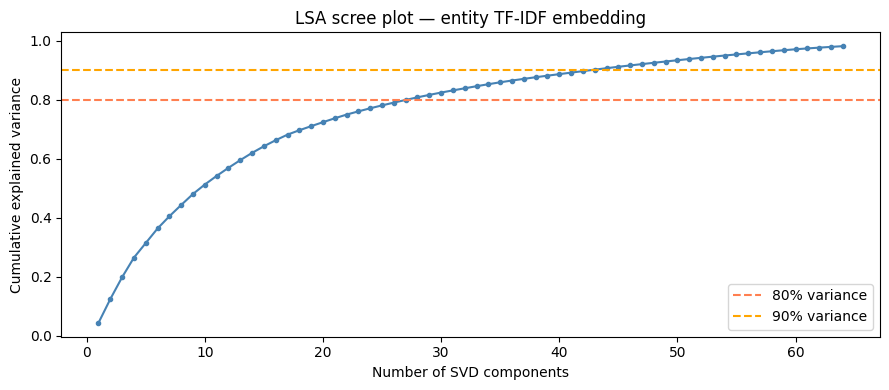

In [4]:
# ── LSA embedding ─────────────────────────────────────────────────────────────
print(f"Running TruncatedSVD ({SVD_COMPONENTS} components) ...")
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_SEED)
Z_svd = normalize(svd.fit_transform(X_filtered), norm="l2")

explained = svd.explained_variance_ratio_.sum()
print(f"LSA embedding shape:  {Z_svd.shape}")
print(f"Explained variance:   {explained:.1%}")

# Scree plot
fig, ax = plt.subplots(figsize=(9, 4))
cumvar = np.cumsum(svd.explained_variance_ratio_)
ax.plot(range(1, SVD_COMPONENTS + 1), cumvar, marker="o", markersize=3, color="steelblue")
ax.axhline(0.80, color="coral",  linestyle="--", label="80% variance")
ax.axhline(0.90, color="orange", linestyle="--", label="90% variance")
ax.set_xlabel("Number of SVD components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("LSA scree plot — entity TF-IDF embedding")
ax.legend()
plt.tight_layout()
plt.savefig(STAGE2_DIR / "01_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

Z_embed = Z_svd   # default embedding used downstream
embed_label = "LSA (TF-IDF + SVD)"

In [5]:
# ── Optional: sentence-transformer embedding ──────────────────────────────────
# Uncomment and run if sentence-transformers + a dataset DataFrame are available.
# The sentence-transformer embedding replaces Z_svd for all downstream steps.
#
# from sentence_transformers import SentenceTransformer
#
# MODEL_NAME = "pritamdeka/S-PubMedBert-MS-MARCO"  # biomedical model
# # MODEL_NAME = "all-MiniLM-L6-v2"              # faster general model
#
# print(f"Loading {MODEL_NAME} ...")
# encoder = SentenceTransformer(MODEL_NAME)
#
# # Build entity-enriched text: raw note + top entity labels appended
# def build_enriched_text(note_text, note_id, count_df, top_k=10):
#     row = count_df.loc[str(note_id)] if str(note_id) in count_df.index else None
#     if row is not None:
#         top_ents = row[row > 0].nlargest(top_k).index.tolist()
#         entity_suffix = " ".join(top_ents)
#         return note_text + " " + entity_suffix
#     return note_text
#
# # Load note texts aligned with ids_filtered
# # note_df = pd.read_csv("stage1_outputs/notes.csv", index_col="idx")
# # texts = [build_enriched_text(note_df.loc[i, "note"], i, count_df) for i in ids_filtered]
#
# # Z_embed = normalize(encoder.encode(texts, batch_size=64, show_progress_bar=True))
# # embed_label = MODEL_NAME
# # print(f"Transformer embedding shape: {Z_embed.shape}")

print("Transformer embedding cell ready (commented out). Using LSA embedding.")

Transformer embedding cell ready (commented out). Using LSA embedding.


## 4. UMAP — 2-D clinical note embedding map

UMAP projects the `N × 64` SVD space to 2 dimensions for visual exploration.
**Clustering is always performed on the full SVD space** (not the 2-D projection)
to avoid distortions introduced by dimensionality reduction.

Running UMAP (2D projection) ...
UMAP 2D shape: (28562, 2)


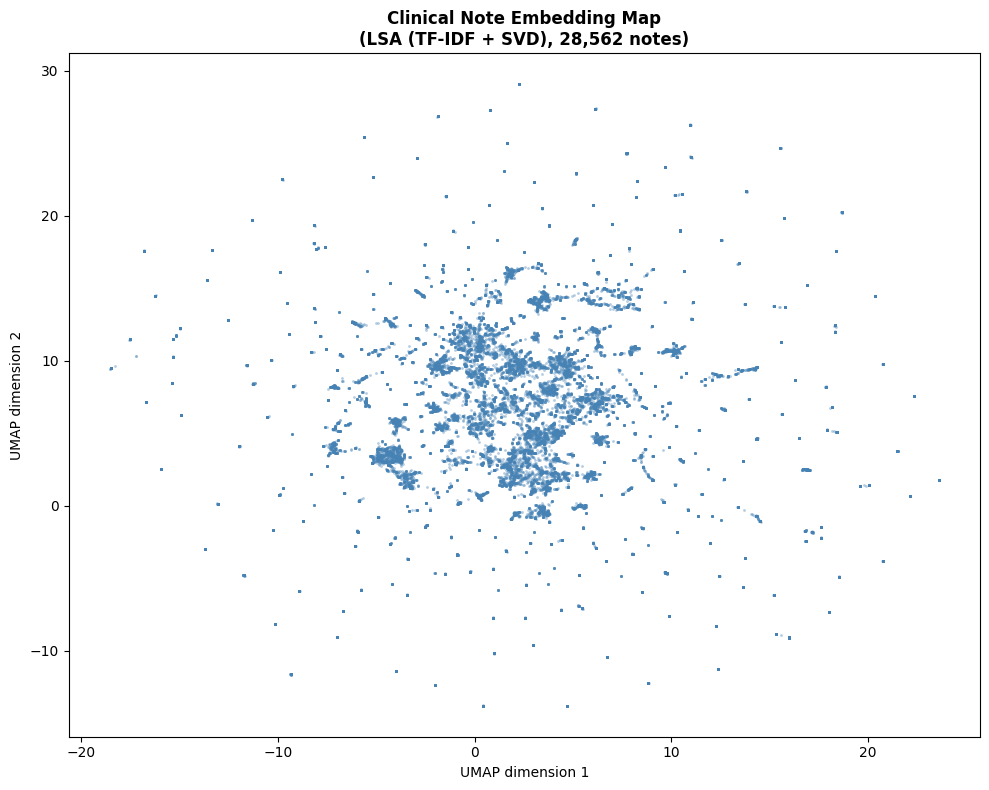

UMAP map saved.


In [6]:
print("Running UMAP (2D projection) ...")
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=RANDOM_SEED,
    verbose=False,
)
Z_2d = reducer_2d.fit_transform(Z_embed)
print(f"UMAP 2D shape: {Z_2d.shape}")

# Save 2D coordinates
umap_df = pd.DataFrame({"note_id": ids_filtered, "x": Z_2d[:, 0], "y": Z_2d[:, 1]})
umap_df.to_csv(STAGE2_DIR / "umap_2d_coords.csv", index=False)

# Raw map (before cluster colouring)
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(Z_2d[:, 0], Z_2d[:, 1], s=4, alpha=0.4, c="steelblue", linewidths=0)
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_title(f"Clinical Note Embedding Map\n({embed_label}, {len(Z_2d):,} notes)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(STAGE2_DIR / "02_umap_raw.png", dpi=150, bbox_inches="tight")
plt.show()
print("UMAP map saved.")

## 5. HDBSCAN phenotypic clustering

We cluster on the full `N × 64` SVD embedding. HDBSCAN advantages for clinical data:
- No pre-specified cluster count
- Handles variable-density clusters (comorbidity load varies across patients)
- Assigns noise label `-1` to atypical/sparse notes rather than forcing cluster membership

We run a **sensitivity analysis** over `min_cluster_size` and pick the value that
maximises silhouette score on non-noise notes.

  mcs=  5 → 1572 clusters, noise=45.3%, silhouette=0.609
  mcs= 10 → 398 clusters, noise=60.9%, silhouette=0.686
  mcs= 20 → 169 clusters, noise=66.1%, silhouette=0.660
  mcs= 30 → 113 clusters, noise=69.1%, silhouette=0.666
  mcs= 50 →  60 clusters, noise=73.8%, silhouette=0.673


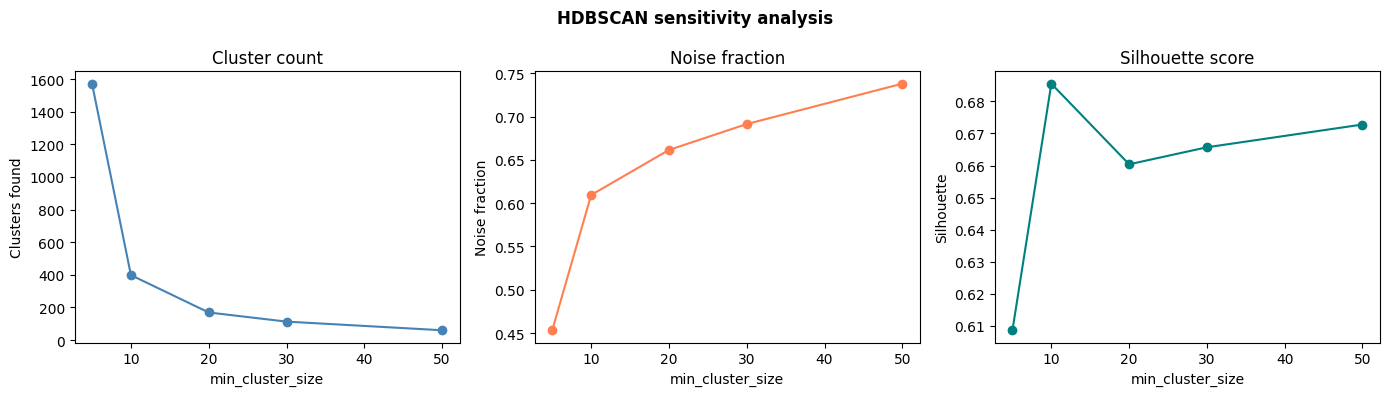

In [7]:
# ── Sensitivity analysis: sweep min_cluster_size ──────────────────────────────
mcs_values   = [5, 10, 20, 30, 50]
sweep_results = []

for mcs in mcs_values:
    cl = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=HDBSCAN_MIN_SAMPLES,
        metric="euclidean",
        prediction_data=True,
    )
    lbs = cl.fit_predict(Z_embed)
    n_clusters = len(set(lbs)) - (1 if -1 in lbs else 0)
    noise_pct  = (lbs == -1).sum() / len(lbs)

    # Silhouette on non-noise notes only
    mask_valid = lbs != -1
    if mask_valid.sum() > 1 and n_clusters > 1:
        sil = silhouette_score(Z_embed[mask_valid], lbs[mask_valid],
                               sample_size=min(2000, mask_valid.sum()),
                               random_state=RANDOM_SEED)
    else:
        sil = float("nan")

    sweep_results.append({"min_cluster_size": mcs, "n_clusters": n_clusters,
                          "noise_pct": noise_pct, "silhouette": sil})
    print(f"  mcs={mcs:3d} → {n_clusters:3d} clusters, noise={noise_pct:.1%}, silhouette={sil:.3f}")

sweep_df = pd.DataFrame(sweep_results)

# Visualise sweep
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(sweep_df.min_cluster_size, sweep_df.n_clusters,   marker="o", color="steelblue")
axes[0].set_xlabel("min_cluster_size"); axes[0].set_ylabel("Clusters found"); axes[0].set_title("Cluster count")
axes[1].plot(sweep_df.min_cluster_size, sweep_df.noise_pct,    marker="o", color="coral")
axes[1].set_xlabel("min_cluster_size"); axes[1].set_ylabel("Noise fraction"); axes[1].set_title("Noise fraction")
axes[2].plot(sweep_df.min_cluster_size, sweep_df.silhouette,   marker="o", color="teal")
axes[2].set_xlabel("min_cluster_size"); axes[2].set_ylabel("Silhouette");     axes[2].set_title("Silhouette score")
plt.suptitle("HDBSCAN sensitivity analysis", fontweight="bold")
plt.tight_layout()
plt.savefig(STAGE2_DIR / "03_hdbscan_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── Final HDBSCAN run ─────────────────────────────────────────────────────────
# Use the pre-configured value or the mcs with best silhouette from the sweep
best_mcs = int(sweep_df.loc[sweep_df.silhouette.idxmax(), "min_cluster_size"])
print(f"Best min_cluster_size by silhouette: {best_mcs}")
print(f"(Override with HDBSCAN_MIN_CLUSTER = {HDBSCAN_MIN_CLUSTER} if preferred)")
final_mcs = HDBSCAN_MIN_CLUSTER   # use configured value; change to best_mcs if preferred

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=final_mcs,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric="euclidean",
    prediction_data=True,
    gen_min_span_tree=True,      # <-- add this; required for DBCV / relative_validity_
)
cluster_labels = clusterer.fit_predict(Z_embed)
n_clusters     = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
noise_count    = (cluster_labels == -1).sum()

# Add to coordinate dataframe
umap_df["cluster"] = cluster_labels
umap_df.to_csv(STAGE2_DIR / "umap_2d_coords.csv", index=False)
np.save(STAGE2_DIR / "cluster_labels.npy", cluster_labels)

print(f"\nClusters found: {n_clusters}")
print(f"Noise notes:    {noise_count} ({noise_count / len(cluster_labels):.1%})")
print("\nCluster sizes:")
for cl, cnt in sorted(pd.Series(cluster_labels).value_counts().items()):
    label = "NOISE" if cl == -1 else f"Cluster {cl:2d}"
    print(f"  {label}: {cnt:>5,} notes")

Best min_cluster_size by silhouette: 10
(Override with HDBSCAN_MIN_CLUSTER = 30 if preferred)

Clusters found: 113
Noise notes:    19745 (69.1%)

Cluster sizes:
  NOISE: 19,745 notes
  Cluster  0:    38 notes
  Cluster  1:    63 notes
  Cluster  2:    38 notes
  Cluster  3:    44 notes
  Cluster  4:    38 notes
  Cluster  5:    35 notes
  Cluster  6:    60 notes
  Cluster  7:    41 notes
  Cluster  8:    37 notes
  Cluster  9:    43 notes
  Cluster 10:    94 notes
  Cluster 11:    35 notes
  Cluster 12:    52 notes
  Cluster 13:    42 notes
  Cluster 14:    48 notes
  Cluster 15:    73 notes
  Cluster 16:    30 notes
  Cluster 17:   106 notes
  Cluster 18:    78 notes
  Cluster 19:    58 notes
  Cluster 20:   120 notes
  Cluster 21:    57 notes
  Cluster 22:    58 notes
  Cluster 23:    30 notes
  Cluster 24:    30 notes
  Cluster 25:    74 notes
  Cluster 26:    77 notes
  Cluster 27:   220 notes
  Cluster 28:    51 notes
  Cluster 29:    44 notes
  Cluster 30:    87 notes
  Cluster 3

## 6. Visualise the embedding map with cluster colours

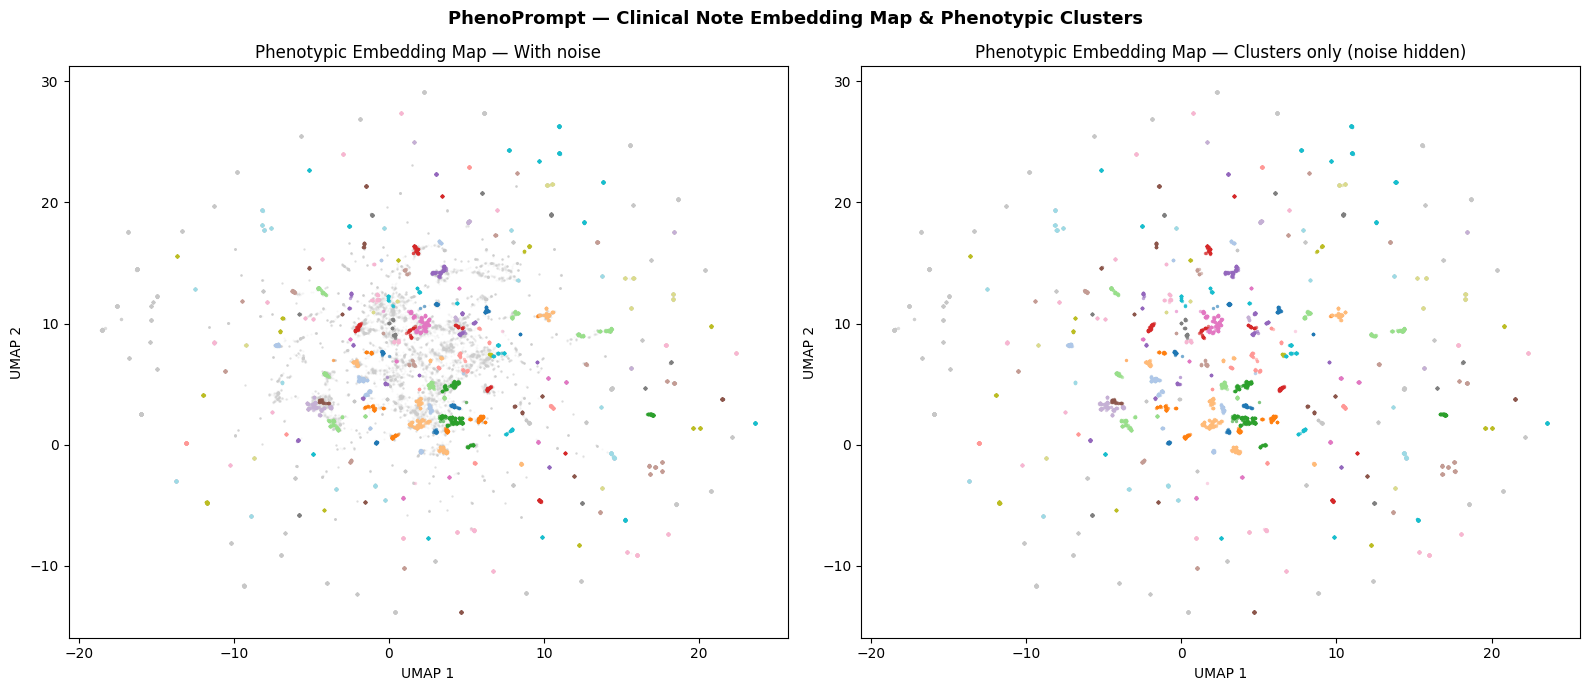

In [9]:
unique_clusters = sorted(set(cluster_labels))
n_cl = len([c for c in unique_clusters if c != -1])
cmap = plt.cm.get_cmap("tab20", max(n_cl, 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, (ax, show_noise) in enumerate(zip(axes, [True, False])):
    for cl in unique_clusters:
        mask = cluster_labels == cl
        if cl == -1:
            if show_noise:
                ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], s=2, alpha=0.15,
                           color="#cccccc", linewidths=0, label="Noise")
        else:
            ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], s=6, alpha=0.6,
                       color=cmap(cl), linewidths=0, label=f"Cluster {cl}")

    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    title = "With noise" if show_noise else "Clusters only (noise hidden)"
    ax.set_title(f"Phenotypic Embedding Map — {title}")
    if n_cl <= 15:
        ax.legend(loc="upper right", fontsize=7, markerscale=3,
                  ncol=2 if n_cl > 8 else 1)

plt.suptitle("PhenoPrompt — Clinical Note Embedding Map & Phenotypic Clusters",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(STAGE2_DIR / "04_umap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Interactive UMAP map (Plotly)

Hover over any point to see its note ID and cluster. Useful for manual cluster inspection.

In [10]:
try:
    import plotly.express as px

    plot_df = umap_df.copy()
    plot_df["cluster_str"] = plot_df["cluster"].apply(
        lambda c: "Noise" if c == -1 else f"Cluster {c}"
    )

    fig = px.scatter(
        plot_df, x="x", y="y", color="cluster_str",
        hover_data={"note_id": True, "cluster": True},
        opacity=0.6, width=900, height=650,
        title="PhenoPrompt — Interactive Clinical Note Embedding Map",
    )
    fig.update_traces(marker=dict(size=4))
    fig.update_layout(legend_title_text="Phenotype cluster")
    fig.write_html(str(STAGE2_DIR / "05_umap_interactive.html"))
    fig.show()
    print("Interactive map saved to stage2_outputs/05_umap_interactive.html")
except ImportError:
    print("plotly not available — skipping interactive map. Run: pip install plotly")

Interactive map saved to stage2_outputs/05_umap_interactive.html


## 8. Cluster quality evaluation

Two complementary metrics (no external labels required):

| Metric | What it measures |
|---|---|
| **Silhouette score** | Intra-cluster cohesion vs inter-cluster separation in the SVD space |
| **DBCV** | Density-based cluster validity (native HDBSCAN quality measure) |

Global silhouette score (non-noise notes): 0.6688
  (Range: -1 worst → +1 best; >0.3 generally indicates meaningful structure)


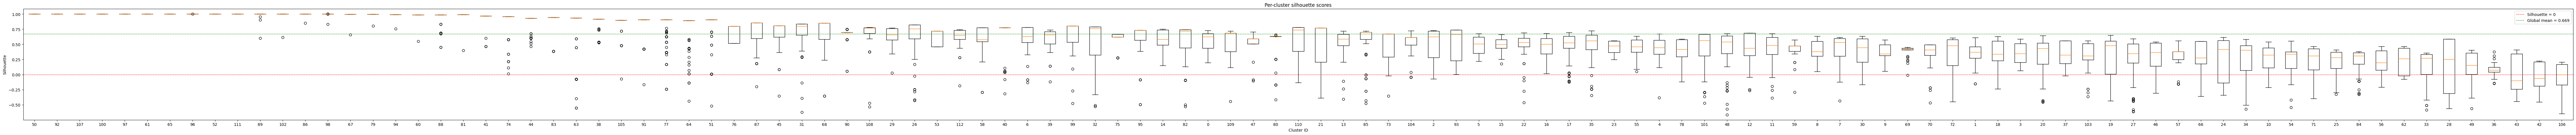


HDBSCAN relative validity (DBCV proxy): 0.1231
  (Higher is better; compare across hyperparameter settings)


In [11]:
valid_mask    = cluster_labels != -1
Z_valid       = Z_embed[valid_mask]
labels_valid  = cluster_labels[valid_mask]

if len(set(labels_valid)) > 1:
    sil_global = silhouette_score(Z_valid, labels_valid,
                                  sample_size=min(3000, len(Z_valid)),
                                  random_state=RANDOM_SEED)
    sil_per    = silhouette_samples(Z_valid, labels_valid)
    print(f"Global silhouette score (non-noise notes): {sil_global:.4f}")
    print("  (Range: -1 worst → +1 best; >0.3 generally indicates meaningful structure)")

    # Per-cluster silhouette box plot
    sil_df = pd.DataFrame({"cluster": labels_valid, "silhouette": sil_per})
    cluster_order = sil_df.groupby("cluster")["silhouette"].mean().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(max(8, n_cl * 0.8), 5))
    # matplotlib >=3.9 removed boxplot(order=...); build it explicitly
    data_by_cluster = [sil_df.loc[sil_df.cluster == cl, "silhouette"].values
                       for cl in cluster_order]
    ax.boxplot(data_by_cluster)
    ax.set_xticks(range(1, len(cluster_order) + 1))
    ax.set_xticklabels([str(cl) for cl in cluster_order])
    ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="Silhouette = 0")
    ax.axhline(sil_global, color="green", linestyle="--",
               linewidth=0.8, label=f"Global mean = {sil_global:.3f}")
    ax.set_title("Per-cluster silhouette scores")
    ax.set_xlabel("Cluster ID")
    ax.set_ylabel("Silhouette")
    plt.suptitle("")
    ax.legend()
    plt.tight_layout()
    plt.savefig(STAGE2_DIR / "06_silhouette.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Only 1 cluster found — increase corpus size or reduce HDBSCAN_MIN_CLUSTER.")

# HDBSCAN internal validity (DBCV)
print(f"\nHDBSCAN relative validity (DBCV proxy): {clusterer.relative_validity_:.4f}")
print("  (Higher is better; compare across hyperparameter settings)")

## 9. Phenotype mix — cluster entity profiles

Each cluster is characterised by a ranked **phenotype mix**: entities that are
both prevalent within the cluster *and* discriminative relative to the full corpus.

$$
\text{score}(e, c) = \frac{p(e \mid c)}{p(e)} \cdot \log\bigl(1 + \text{count}(e, c)\bigr)
$$

This is a TF-IDF-style measure: $p(e \mid c)$ is the within-cluster prevalence;
$p(e)$ is the corpus-wide prevalence (the IDF component).

In [12]:
def compute_phenotype_mix(count_df: pd.DataFrame,
                          cluster_labels: np.ndarray,
                          note_ids: np.ndarray,
                          top_k: int = 10) -> dict:
    """
    Compute the phenotype mix for every cluster.

    Parameters
    ----------
    count_df      : (N_notes × V_entities) raw entity count matrix
    cluster_labels: HDBSCAN cluster assignment per note (-1 = noise)
    note_ids      : note IDs aligned with cluster_labels
    top_k         : entities to return per cluster

    Returns
    -------
    dict  {cluster_id: DataFrame(entity, score, prevalence_in_cluster, prevalence_corpus)}
    """
    # Align count_df rows to the note_ids order used for clustering
    idx_str   = [str(i) for i in note_ids]
    aligned   = count_df.reindex(idx_str, fill_value=0)

    corpus_prev  = (aligned > 0).mean()                 # p(e) across all notes
    phenomix     = {}

    for cl in sorted(set(cluster_labels)):
        if cl == -1:
            continue
        members      = aligned.loc[np.array(idx_str)[cluster_labels == cl]]
        cluster_prev = (members > 0).mean()             # p(e | c)
        cluster_cnt  = members.sum()                    # count(e, c)

        score = (cluster_prev / (corpus_prev + 1e-8)) * np.log1p(cluster_cnt)
        top   = score.nlargest(top_k)

        phenomix[cl] = pd.DataFrame({
            "entity":              top.index,
            "score":               top.values.round(4),
            "prevalence_cluster":  cluster_prev[top.index].values.round(3),
            "prevalence_corpus":   corpus_prev[top.index].values.round(3),
            "count_in_cluster":    cluster_cnt[top.index].astype(int).values,
        }).reset_index(drop=True)

    return phenomix


phenomix = compute_phenotype_mix(
    count_df, cluster_labels, ids_filtered, top_k=PHENOMIX_TOP_K
)

print(f"Phenotype mix computed for {len(phenomix)} clusters.")
print("\nPreview — Cluster 0:")
print(phenomix[0].to_string(index=False) if 0 in phenomix else "Cluster 0 not found.")

Phenotype mix computed for 113 clusters.

Preview — Cluster 0:
entity    score  prevalence_cluster  prevalence_corpus  count_in_cluster
   CKD 445.8030               1.000              0.010                71
  PALP  14.9638               0.132              0.016                 5
STROKE  10.6715               0.132              0.022                 5
   HTN   9.3499               0.447              0.143                19
  SSRI   7.0883               0.026              0.005                 3
    DM   4.1100               0.184              0.093                 7
    BX   3.1058               0.211              0.184                14
   FAT   2.6812               0.158              0.115                 6
   CCB   2.4928               0.026              0.007                 1
    CT   1.6982               0.237              0.321                 9


In [13]:
# ── Print all cluster profiles ────────────────────────────────────────────────
cluster_sizes = pd.Series(cluster_labels).value_counts().drop(-1, errors="ignore").sort_index()

for cl, mix_df in sorted(phenomix.items()):
    size = cluster_sizes.get(cl, 0)
    print(f"\n{'='*55}")
    print(f" Cluster {cl:2d}  |  {size:,} notes")
    print(f"{'='*55}")
    print(mix_df.to_string(index=False))


 Cluster  0  |  38 notes
entity    score  prevalence_cluster  prevalence_corpus  count_in_cluster
   CKD 445.8030               1.000              0.010                71
  PALP  14.9638               0.132              0.016                 5
STROKE  10.6715               0.132              0.022                 5
   HTN   9.3499               0.447              0.143                19
  SSRI   7.0883               0.026              0.005                 3
    DM   4.1100               0.184              0.093                 7
    BX   3.1058               0.211              0.184                14
   FAT   2.6812               0.158              0.115                 6
   CCB   2.4928               0.026              0.007                 1
    CT   1.6982               0.237              0.321                 9

 Cluster  1  |  63 notes
 entity    score  prevalence_cluster  prevalence_corpus  count_in_cluster
     FQ 463.1578               1.000              0.010               1

## 10. Phenotype mix visualisation

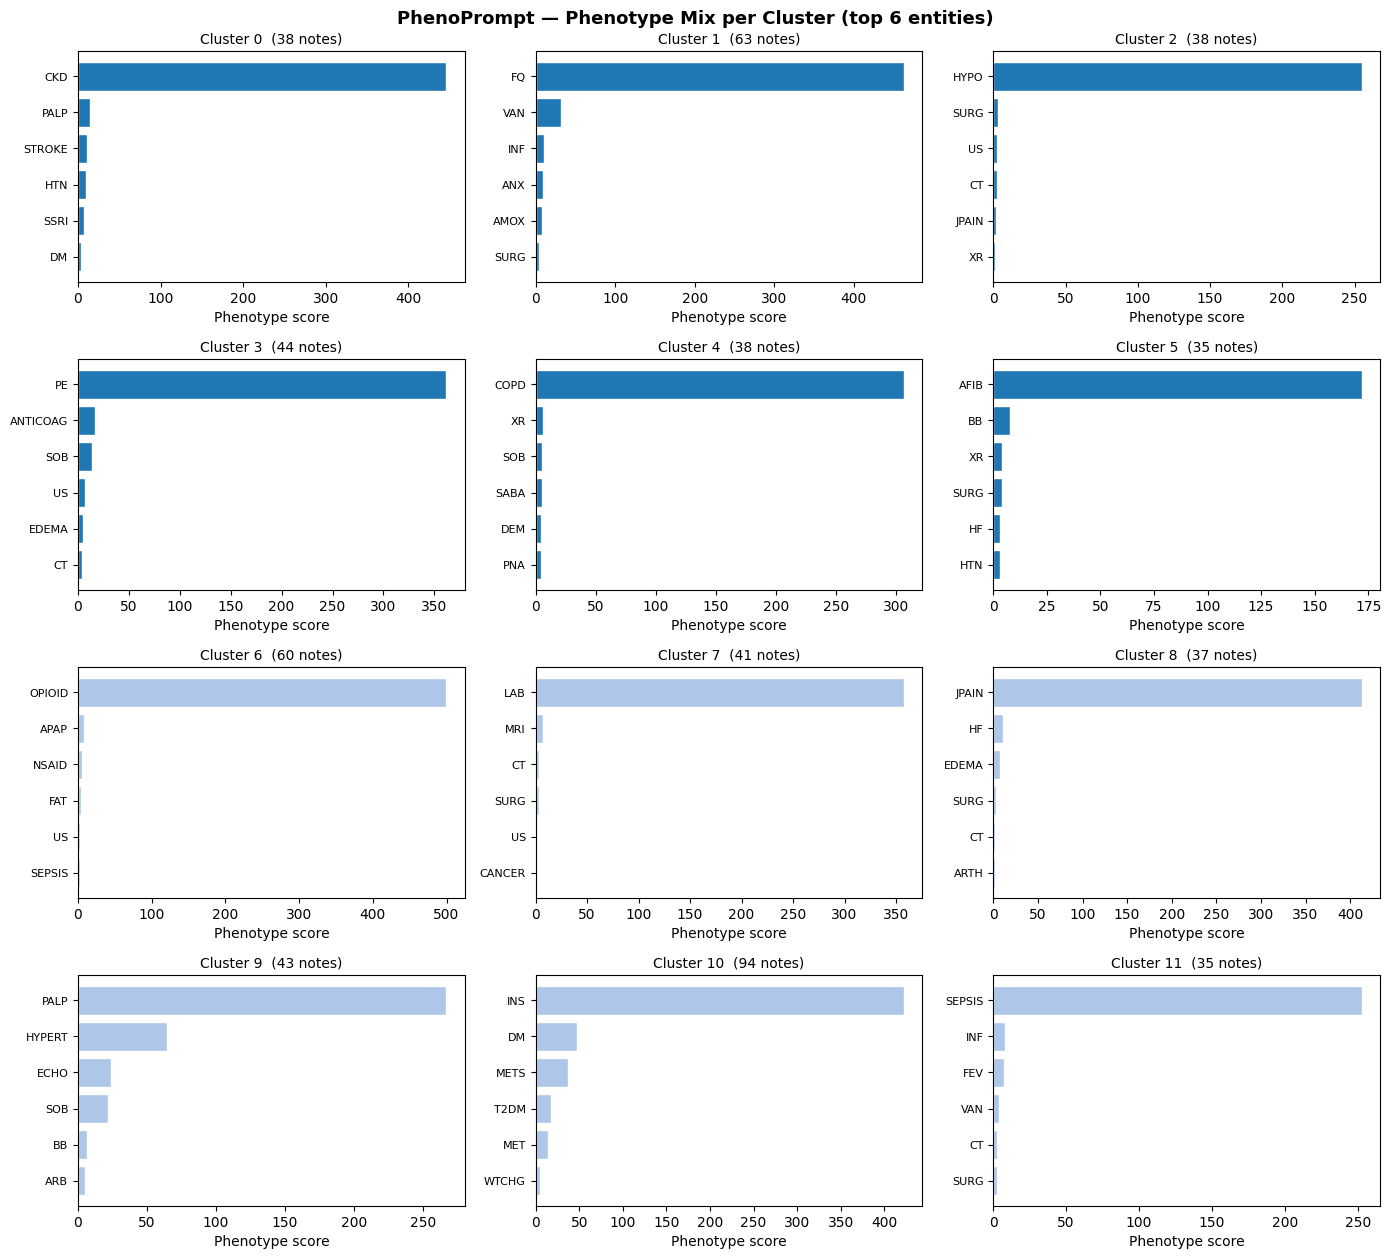

In [14]:
# ── Bar chart grid — top-6 entities per cluster ───────────────────────────────
visible_clusters = [cl for cl in sorted(phenomix) if cluster_sizes.get(cl, 0) >= 5]
n_show = min(len(visible_clusters), 12)    # max 12 panels
ncols  = 3
nrows  = (n_show + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax_i, cl in enumerate(visible_clusters[:n_show]):
    mix  = phenomix[cl].head(6)
    size = cluster_sizes.get(cl, 0)
    ax   = axes_flat[ax_i]
    colors_ = [cmap(cl)] * len(mix)
    ax.barh(mix["entity"][::-1], mix["score"][::-1], color=colors_, edgecolor="white")
    ax.set_title(f"Cluster {cl}  ({size:,} notes)", fontsize=10)
    ax.set_xlabel("Phenotype score")
    ax.tick_params(axis="y", labelsize=8)

for ax_i in range(n_show, len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle("PhenoPrompt — Phenotype Mix per Cluster (top 6 entities)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(STAGE2_DIR / "07_phenomix_grid.png", dpi=150, bbox_inches="tight")
plt.show()

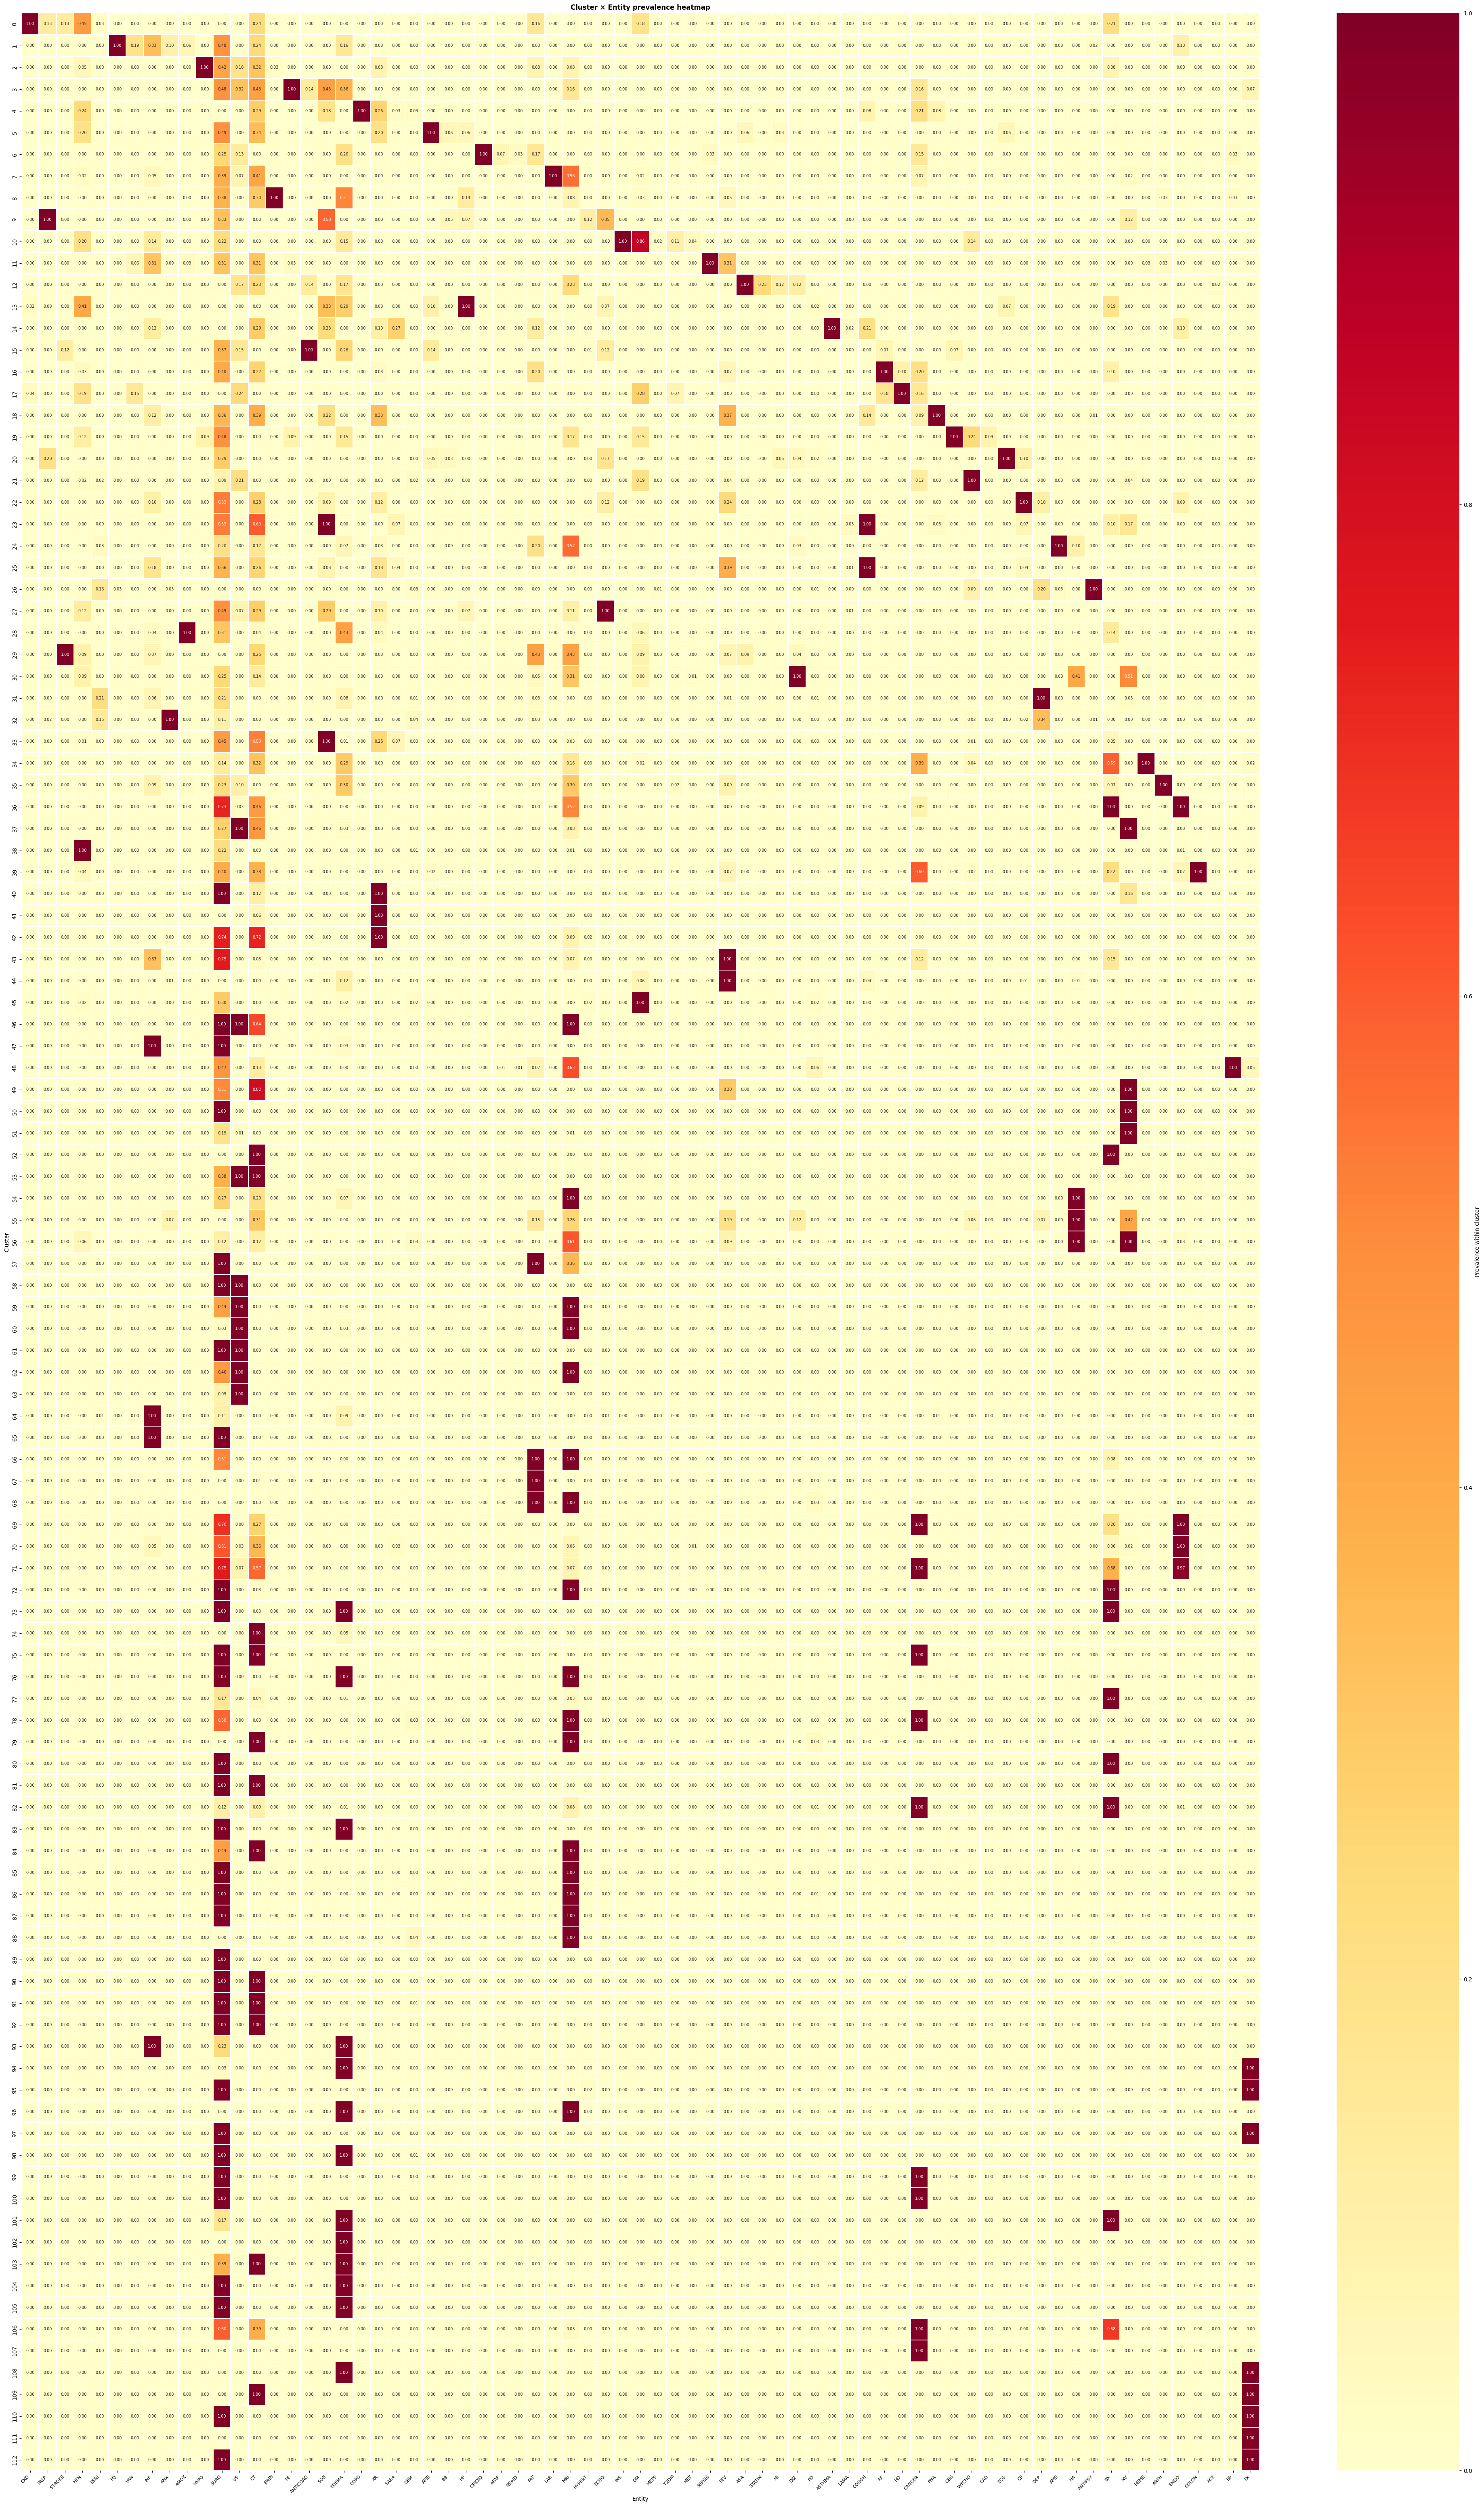

In [15]:
# ── Heatmap: cluster × top entities ──────────────────────────────────────────
# Gather all top-5 entities across clusters into a shared vocabulary
all_top_ents = []
for mix_df in phenomix.values():
    all_top_ents.extend(mix_df["entity"].head(5).tolist())
shared_ents = list(dict.fromkeys(all_top_ents))   # preserve insertion order, deduplicate

heat_data = pd.DataFrame(index=sorted(phenomix.keys()), columns=shared_ents, dtype=float).fillna(0)
for cl, mix_df in phenomix.items():
    for _, row in mix_df.iterrows():
        if row["entity"] in heat_data.columns:
            heat_data.loc[cl, row["entity"]] = row["prevalence_cluster"]

fig, ax = plt.subplots(figsize=(max(10, len(shared_ents) * 0.55), max(5, len(phenomix) * 0.55)))
sns.heatmap(heat_data, ax=ax, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            annot=True, fmt=".2f", annot_kws={"size": 7},
            cbar_kws={"label": "Prevalence within cluster"})
ax.set_xlabel("Entity")
ax.set_ylabel("Cluster")
ax.set_title("Cluster × Entity prevalence heatmap", fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(STAGE2_DIR / "08_cluster_entity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Save Stage 2 outputs

All artefacts needed for Stage 3 (RAG prompt interface) are written to `stage2_outputs/`.

In [16]:
# ── Cluster assignment table ───────────────────────────────────────────────────
cluster_df = pd.DataFrame({"note_id": ids_filtered, "cluster": cluster_labels})
cluster_df.to_csv(STAGE2_DIR / "cluster_assignments.csv", index=False)

# ── Phenotype mix — one CSV per cluster + combined JSON ───────────────────────
all_mix_rows = []
for cl, mix_df in phenomix.items():
    mix_df = mix_df.copy()
    mix_df["cluster"] = cl
    all_mix_rows.append(mix_df)
    mix_df.to_csv(STAGE2_DIR / f"phenomix_cluster_{cl:02d}.csv", index=False)

combined_mix = pd.concat(all_mix_rows, ignore_index=True)
combined_mix.to_csv(STAGE2_DIR / "phenomix_all_clusters.csv", index=False)

# ── JSON phenotype profiles (for Stage 3 RAG index) ─────────────────────────
import json
profiles = {}
for cl, mix_df in phenomix.items():
    profiles[str(cl)] = {
        "cluster_id":  cl,
        "n_notes":     int(cluster_sizes.get(cl, 0)),
        "top_entities": mix_df[["entity", "score", "prevalence_cluster"]].to_dict(orient="records"),
    }
def _to_native(o):
    """Convert NumPy types to native Python for JSON serialization."""
    import numpy as np
    if isinstance(o, (np.integer,)):   return int(o)
    if isinstance(o, (np.floating,)):  return float(o)
    if isinstance(o, (np.ndarray,)):   return o.tolist()
    raise TypeError(f"Not serializable: {type(o)}")

(STAGE2_DIR / "phenotype_profiles.json").write_text(
    json.dumps(profiles, indent=2, default=_to_native)
)

# ── Embeddings (for Stage 3 FAISS index) ─────────────────────────────────────
np.save(STAGE2_DIR / "svd_embeddings.npy",  Z_embed)
np.save(STAGE2_DIR / "umap_2d_coords.npy",  Z_2d)

print("Stage 2 outputs saved to", STAGE2_DIR)
for f in sorted(STAGE2_DIR.iterdir()):
    print(f"  {f.name:40s}  {f.stat().st_size / 1024:8.1f} KB")

Stage 2 outputs saved to /content/drive/MyDrive/phenoprompt/stage2_outputs
  01_scree_plot.png                             57.2 KB
  02_umap_raw.png                              183.0 KB
  03_hdbscan_sweep.png                          95.7 KB
  04_umap_clusters.png                         182.6 KB
  05_umap_interactive.html                    5436.7 KB
  06_silhouette.png                            234.0 KB
  07_phenomix_grid.png                         159.1 KB
  08_cluster_entity_heatmap.png               1081.2 KB
  cluster_assignments.csv                      264.4 KB
  cluster_labels.npy                           223.3 KB
  phenomix_all_clusters.csv                     29.5 KB
  phenomix_cluster_00.csv                        0.3 KB
  phenomix_cluster_01.csv                        0.3 KB
  phenomix_cluster_02.csv                        0.3 KB
  phenomix_cluster_03.csv                        0.4 KB
  phenomix_cluster_04.csv                        0.3 KB
  phenomix_cluster_05.csv    

## 12. Stage 2 summary

In [17]:
valid_mask   = cluster_labels != -1
labels_valid = cluster_labels[valid_mask]

if len(set(labels_valid)) > 1:
    sil_final = silhouette_score(Z_embed[valid_mask], labels_valid,
                                 sample_size=min(3000, valid_mask.sum()),
                                 random_state=RANDOM_SEED)
else:
    sil_final = float("nan")

print("=" * 55)
print("PHENOPROMPT — STAGE 2 SUMMARY")
print("=" * 55)
print(f"  Notes embedded:         {len(Z_embed):>8,}")
print(f"  Embedding method:       {embed_label}")
print(f"  Embedding dimensions:   {Z_embed.shape[1]:>8}")
print(f"  UMAP projection:        2D (cosine, n_neighbors={UMAP_NEIGHBORS})")
print(f"  HDBSCAN min_cluster:    {final_mcs:>8}")
print(f"  Phenotypic clusters:    {n_clusters:>8}")
print(f"  Noise notes:            {noise_count:>8,}  ({noise_count/len(cluster_labels):.1%})")
print(f"  Silhouette score:       {sil_final:>8.4f}")
print(f"  DBCV (rel. validity):   {clusterer.relative_validity_:>8.4f}")
print("")
print(f"Cluster summary:")
for cl in sorted(phenomix):
    sz    = cluster_sizes.get(cl, 0)
    top3  = ", ".join(phenomix[cl]["entity"].head(3).tolist())
    print(f"  Cluster {cl:2d}  ({sz:>5,} notes)  top-3: {top3}")
print("="*55)
print()
print("Stage 2 complete. Load stage2_outputs/ in Stage 3 (prompt RAG) notebook.")

PHENOPROMPT — STAGE 2 SUMMARY
  Notes embedded:           28,562
  Embedding method:       LSA (TF-IDF + SVD)
  Embedding dimensions:         64
  UMAP projection:        2D (cosine, n_neighbors=15)
  HDBSCAN min_cluster:          30
  Phenotypic clusters:         113
  Noise notes:              19,745  (69.1%)
  Silhouette score:         0.6688
  DBCV (rel. validity):     0.1231

Cluster summary:
  Cluster  0  (   38 notes)  top-3: CKD, PALP, STROKE
  Cluster  1  (   63 notes)  top-3: FQ, VAN, INF
  Cluster  2  (   38 notes)  top-3: HYPO, SURG, US
  Cluster  3  (   44 notes)  top-3: PE, ANTICOAG, SOB
  Cluster  4  (   38 notes)  top-3: COPD, XR, SOB
  Cluster  5  (   35 notes)  top-3: AFIB, BB, XR
  Cluster  6  (   60 notes)  top-3: OPIOID, APAP, NSAID
  Cluster  7  (   41 notes)  top-3: LAB, MRI, CT
  Cluster  8  (   37 notes)  top-3: JPAIN, HF, EDEMA
  Cluster  9  (   43 notes)  top-3: PALP, HYPERT, ECHO
  Cluster 10  (   94 notes)  top-3: INS, DM, METS
  Cluster 11  (   35 notes)  